Assignment done by Group 7:

- Sri Vidya Yeluripati
- Pudharikaksha Jayendra Kavipurapu
- Mayank Mayank

# Exercise 2

**Please Note**: We updated the requirements.txt

Please install the new requirements before editing this exercise.

## Import packages

In [6]:
import os

from vll.utils.download import download_mnist
import numpy as np
import matplotlib.pyplot as plt



import torch
import torch.nn.functional as F
from torchvision import transforms

from models.mnist.simple_cnn import Net

## Task 1
(2 points)

In this task, you will learn some basic tensor operations using the PyTorch library.

Reference for torch: https://pytorch.org/docs/stable/torch.html

In [ ]:
# Create a numpy array that looks like this: [0, 1, 2, ..., 19]
arr = np.arange(20, dtype=np.int64)

# Convert the numpy array to a torch tensor
tensor = torch.from_numpy(arr).float()
print(tensor)

# Create a tensor that contains random numbers.
# It should have the same size like the numpy array.
# Multiply it with the previous tensor.
rand_tensor = torch.rand_like(tensor)
tensor = tensor * rand_tensor
print(tensor)

# Create a tensor that contains only 1s.
# It should have the same size like the numpy array.
# Substract it from the previous tensor.
tensor = tensor - torch.ones_like(tensor)
print(tensor)

# Get the 5th element using a index.
element = tensor[4]
print(element)

# Create a tensor that contains only 0s.
# It should have the same size like the numpy array.
# Multiply it with the previous tensor without any assignment (in place).
zeros = torch.zeros_like(tensor)
tensor.mul_(zeros)
print(tensor)


# Create a tensor that contains only 0s.
# It should have the same size like the numpy array.
# Multiply it with the previous tensor without any assignment (in place).


tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.])
tensor([ 0.0000,  0.4140,  1.2836,  0.1422,  3.9528,  0.1612,  5.4926,  5.5076,
         1.6833,  2.0596,  5.6309,  6.9187,  0.6071,  2.6280,  9.7431,  8.4432,
        11.2317, 13.7154,  0.4527, 16.0892])
tensor([-1.0000, -0.5860,  0.2836, -0.8578,  2.9528, -0.8388,  4.4926,  4.5076,
         0.6833,  1.0596,  4.6309,  5.9187, -0.3929,  1.6280,  8.7431,  7.4432,
        10.2317, 12.7154, -0.5473, 15.0892])
tensor(2.9528)
tensor([-0., -0., 0., -0., 0., -0., 0., 0., 0., 0., 0., 0., -0., 0., 0., 0., 0., 0., -0., 0.])


In [8]:

# Load the image from the last exercise as RGB image.
from PIL import Image
import glob

# find the most recently modified image file in the data/ tree
exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
candidates = sorted(
    [p for p in glob.glob('data/**/*', recursive=True) if p.lower().endswith(exts)],
    key=os.path.getmtime
)
if not candidates:
    raise FileNotFoundError("No image files found under data/. Place the image there.")
image_path = candidates[-1]
image = Image.open(image_path).convert('RGB')

# Convert the image to a tensor
to_tensor = transforms.ToTensor()
image = to_tensor(image)  # shape: (C, H, W)

# Print its shape
print(image.shape)

# Keep original shape for later
orig_shape = image.shape
num_elements = image.numel()

# Flatten the image
image = image.view(-1)
print(len(image))

# Add another dimension resulting in a 1xN tensor
image = image.unsqueeze(0)
print(image.shape)

# Revert the last action
image = image.squeeze(0)
print(image.shape)

# Reshape the tensor, so that it has the original 3D dimensions (C, H, W)
image = image.view(orig_shape)
print(image.shape)

# Calculate the sum, mean and max of the tensor
print(torch.sum(image))
print(torch.mean(image))
print(torch.max(image))


torch.Size([3, 512, 512])
786432
torch.Size([1, 786432])
torch.Size([786432])
torch.Size([3, 512, 512])
tensor(358450.3750)
tensor(0.4558)
tensor(1.)


## Task 2
(2 points)

Use Autograd to perform operations on a tensor and output then gradients.

In [9]:

# Create a random 2x2 tensor which requires gradients
x = torch.randn(2, 2, requires_grad=True)
print(x)

# Create another tensor by adding 2.0
y = x + 2.0
print(y)

# Create a third tensor z = y^2
z = y ** 2
print(z)

# Compute out as the mean of values in z
out = z.mean()
print(out)

# Perform back propagation on out
out.backward()

# Print the gradients dout/dx
print(x.grad)

# Create a copy of y whithout gradients
y2 = y.detach()
print(y2.requires_grad)

# Perform the mean operation on z
# with gradients globally disabled
with torch.no_grad():
    mean_z = z.mean()
print(mean_z)


tensor([[-0.1708, -1.7251],
        [-0.5271, -0.0082]], requires_grad=True)
tensor([[1.8292, 0.2749],
        [1.4729, 1.9918]], grad_fn=<AddBackward0>)
tensor([[3.3459, 0.0755],
        [2.1695, 3.9673]], grad_fn=<PowBackward0>)
tensor(2.3896, grad_fn=<MeanBackward0>)
tensor([[0.9146, 0.1374],
        [0.7365, 0.9959]])
False
tensor(2.3896)


## Task 3
(3 points)

Implement a Dataset class for MNIST.

In [10]:
# We first download the MNIST dataset
download_mnist()

Extract mnist.tar.gz
Done!


In [11]:

class MNIST:
    """
    Dataset class for MNIST
    """

    def __init__(self, root, transform=None):
        """
        root -- path to either "training" or "testing"
        
        transform -- transform (from torchvision.transforms)
                     to be applied to the data
        """
        # save transforms
        self.transform = transform
        
        # list of class subdirectories (e.g. '0','1',...)
        class_dirs = sorted(
            [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
        )
        self.classes = class_dirs

        # create list of (image_path, label) pairs
        self.samples = []
        for cls in class_dirs:
            cls_path = os.path.join(root, cls)
            # include any file in the class folder
            for img_path in sorted(glob.glob(os.path.join(cls_path, "*"))):
                # try to parse label from directory name
                try:
                    label = int(cls)
                except ValueError:
                    # fallback: use index of class_dirs
                    label = class_dirs.index(cls)
                self.samples.append((img_path, label))
    
    def __len__(self):
        """
        Returns the lenght of the dataset (number of images)
        """
        return len(self.samples)

    def __getitem__(self, index):
        """
        Loads and returns one image as floating point numpy array (or transformed)
        
        index -- image index in [0, self.__len__() - 1]
        """
        img_path, label = self.samples[index]
        # load as PIL image (MNIST is grayscale)
        image = Image.open(img_path).convert("L")

        # apply transforms if provided (e.g. ToTensor + Normalize)
        if self.transform is not None:
            image = self.transform(image)
        else:
            # return numpy float32 in [0,1]
            image = np.array(image, dtype=np.float32) / 255.0

        return image, label


## Task 4
(3 points)

You can now load a pretrained neural network model we provide.
Your last task is to run the model on the MNIST test dataset, plot some example images with the predicted labels and compute the prediction accuracy.

/usr/local/python/3.12.1/lib/python3.12/site-packages/torch/nn/functional.py:1531: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


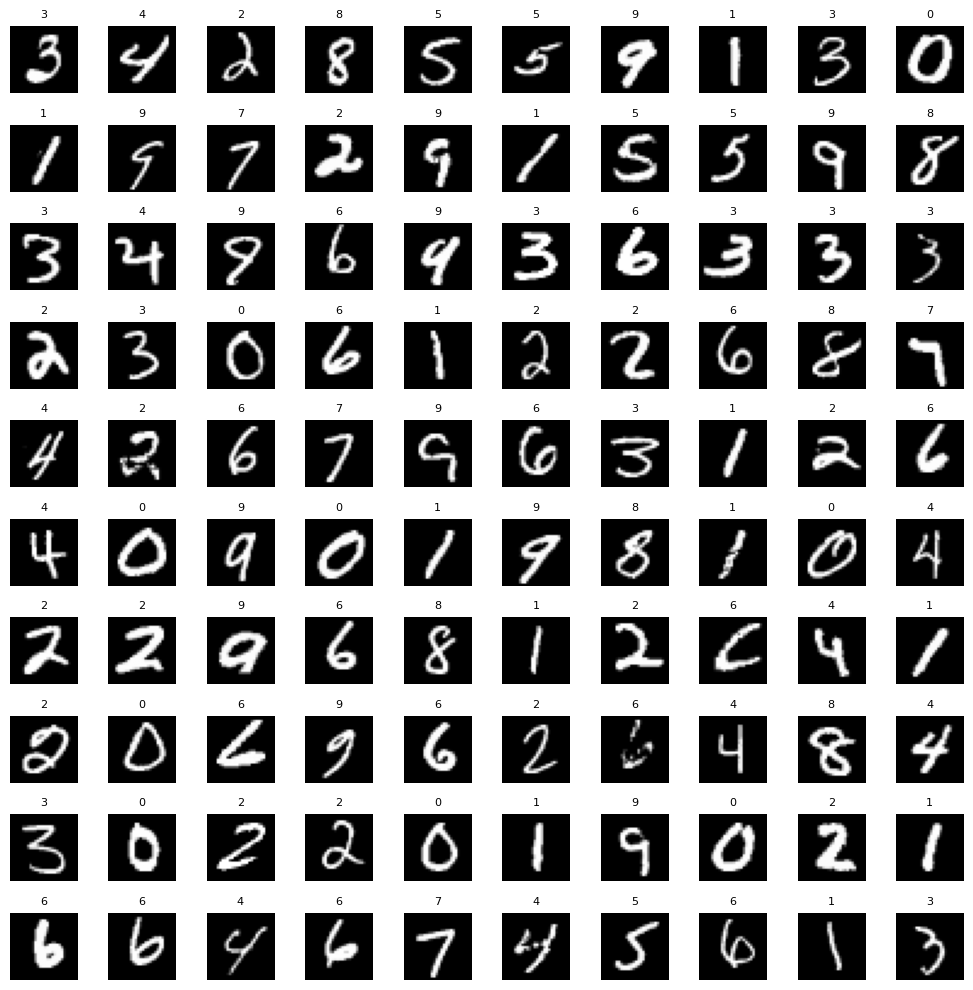

Accuracy: 98.32%


In [ ]:

def validate(model, data_loader):
    # Create a 10x10 grid of subplots
    fig, axes = plt.subplots(10, 10, figsize=(10, 10))
    axes = axes.flatten()

    model.eval()
    correct = 0  # count for correct predictions

    # determine model device (fallback to cpu)
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device('cpu')

    with torch.no_grad():
        for i, item in enumerate(data_loader):
            # unpack item into image and ground truth and run network on them
            image, gt = item

            # normalize gt to a python int
            if isinstance(gt, torch.Tensor):
                gt_item = int(gt.item()) if gt.numel() == 1 else int(gt[0].item())
            elif isinstance(gt, (list, tuple)):
                gt_item = int(gt[0])
            else:
                gt_item = int(gt)

            image = image.to(device)  # shape: (batch, C, H, W)
            outputs = model(image)

            # get class with highest probability (handle batch size 1)
            preds = outputs.argmax(dim=1)
            pred_item = int(preds.item()) if preds.numel() == 1 else int(preds[0].item())

            # check if prediction is correct and add it to correct count
            correct += int(pred_item == gt_item)

            # plot the first 100 images
            if i < 100:
                ax = axes[i]

                # convert image tensor to numpy array and normalize to [0, 1]
                # image was normalized with mean=0.1307 and std=0.3081
                img = image.cpu().squeeze().clone()  # may be (1,H,W) or (H,W)
                # ensure single channel 2D
                if img.ndim == 3:
                    img = img[0]
                img = img * 0.3081 + 0.1307
                img = img.clamp(0.0, 1.0).numpy()

                # show image (grayscale)
                ax.imshow(img, cmap='gray', vmin=0, vmax=1)

                # make wrongly predicted images red
                if pred_item != gt_item:
                    for spine in ax.spines.values():
                        spine.set_edgecolor('red')
                        spine.set_linewidth(2.0)

                # disable axis and show image
                ax.axis('off')

                # show the predicted class next to each image (title)
                ax.set_title(str(pred_item), color=('red' if pred_item != gt_item else 'black'), fontsize=8)

            elif i == 100:
                plt.tight_layout()
                plt.show()

    # compute and print the prediction accuracy in percent
    total = len(data_loader.dataset) if hasattr(data_loader, 'dataset') else len(data_loader)
    accuracy = 100.0 * correct / total if total > 0 else 0.0
    print(f'Accuracy: {accuracy:.2f}%')

# create a DataLoader using the implemented MNIST dataset class
data_loader = torch.utils.data.DataLoader(
    MNIST('data/mnist/testing',
          transform=transforms.Compose([
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
          ])),
    batch_size=1, shuffle=True)

# create the neural network
model = Net()

# load the statedict from 'models/mnist/simple_cnn.pt'
model.load_state_dict(torch.load('models/mnist/simple_cnn.pt'))

# validate the model
validate(model, data_loader)
